In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import sys
import json
from pathlib import Path
import pandas as pd

In [45]:
# where WellClass and Ga[ codes are located
sys.path.append('../')

In [46]:
from src.WellClass.libs.models.well_model import WellModel
from src.WellClass.libs.well_class   import WellProcessed

from src.WellClass.libs.well_class   import Well
from src.WellClass.libs.plotting.plot_sketch import plot_sketch

In [47]:
frigg_json = '../test_data/examples/frigg/frigg.json'

json_data = json.load(open(frigg_json))


my_model = WellModel(**json_data)

In [56]:
my_well = Well.from_json(frigg_json)

In [57]:
my_well.plot()

AttributeError: 'Well' object has no attribute 'plot'

In [58]:
example_path = frigg_json

with open(example_path, 'r', encoding='utf-8') as f:
    my_well_dict = json.load(f)

my_well_dict['spec']['hole_casings'][0]['diameter_in']

36.0

In [63]:
info = my_well.plugs
info_gt = my_well_dict['spec']['plugs']

In [60]:
# section index
sec_index = 1

assert info[sec_index]['diameter_in'] == info_gt[sec_index]['diameter_in']
assert info[sec_index]['top_rkb'] == info_gt[sec_index]['top_rkb']
assert info[sec_index]['bottom_rkb'] == info_gt[sec_index]['bottom_rkb']

In [53]:
# section index
sec_index = 5

assert info[sec_index]['diameter_in'] == info_gt[sec_index]['diameter_in']
assert info[sec_index]['top_rkb'] == info_gt[sec_index]['top_rkb']
assert info[sec_index]['bottom_rkb'] == info_gt[sec_index]['bottom_rkb']

# compare the whole dictionary
assert info == info_gt

AssertionError: 

In [64]:
info

[{'name': 'cplug9',
  'type': 'cement',
  'top_rkb': 148.0,
  'bottom_rkb': 230.0,
  'cement_perm': None},
 {'name': 'cplug8',
  'type': 'cement',
  'top_rkb': 230.0,
  'bottom_rkb': 370.0,
  'cement_perm': None},
 {'name': 'cplug7',
  'type': 'cement',
  'top_rkb': 604.0,
  'bottom_rkb': 721.0,
  'cement_perm': None},
 {'name': 'cplug6',
  'type': 'cement',
  'top_rkb': 721.0,
  'bottom_rkb': 835.0,
  'cement_perm': None},
 {'name': 'bplug2',
  'type': 'mechanical plug',
  'top_rkb': 3842.0,
  'bottom_rkb': 3842.5,
  'cement_perm': None},
 {'name': 'cplug5',
  'type': 'cement',
  'top_rkb': 3847.0,
  'bottom_rkb': 3981.0,
  'cement_perm': None},
 {'name': 'bplug1',
  'type': 'mechanical plug',
  'top_rkb': 4156.0,
  'bottom_rkb': 4156.5,
  'cement_perm': None},
 {'name': 'cplug4',
  'type': 'cement',
  'top_rkb': 4164.0,
  'bottom_rkb': 4532.0,
  'cement_perm': None},
 {'name': 'cplug3',
  'type': 'cement',
  'top_rkb': 4534.0,
  'bottom_rkb': 4735.0,
  'cement_perm': None}]

In [65]:
info_gt

[{'name': 'cplug9', 'type': 'cement', 'top_rkb': 148.0, 'bottom_rkb': 230.0},
 {'name': 'cplug8', 'type': 'cement', 'top_rkb': 230.0, 'bottom_rkb': 370.0},
 {'name': 'cplug7', 'type': 'cement', 'top_rkb': 604.0, 'bottom_rkb': 721.0},
 {'name': 'cplug6', 'type': 'cement', 'top_rkb': 721.0, 'bottom_rkb': 835.0},
 {'name': 'bplug2',
  'type': 'mechanical plug',
  'top_rkb': 3842.0,
  'bottom_rkb': 3842.5},
 {'name': 'cplug5', 'type': 'cement', 'top_rkb': 3847.0, 'bottom_rkb': 3981.0},
 {'name': 'bplug1',
  'type': 'mechanical plug',
  'top_rkb': 4156.0,
  'bottom_rkb': 4156.5},
 {'name': 'cplug4', 'type': 'cement', 'top_rkb': 4164.0, 'bottom_rkb': 4532.0},
 {'name': 'cplug3', 'type': 'cement', 'top_rkb': 4534.0, 'bottom_rkb': 4735.0}]

In [56]:
df[~df["shoe"].astype(bool)]

,name,type,top_rkb,bottom_rkb,diameter_in,shoe,hc_perm,tvd_msl_top,tvd_msl_bottom,diameter_m
0,Hole 36 in,hole,126.0,189.0,36.000,False,None,98.99827266276596,161.9965799228727,0.914400
1,Hole 26 in,hole,189.0,923.0,26.000,False,None,161.9965799228727,895.9427446136193,0.660400
2,Hole 17 1/2 in,hole,923.0,2839.0,17.500,False,None,895.9427446136193,2811.286861302984,0.444500
3,Hole 12 1/4 in,hole,2839.0,4085.0,12.250,False,None,2811.286861302984,4054.1796124287093,0.311150
4,Hole 8 3/8 in,hole,4085.0,4470.0,8.375,False,None,4054.1796124287093,4436.829077396368,0.212725
5,Hole 5 7/8 in,hole,4470.0,4739.0,5.875,False,None,4436.829077396368,4704.694542342855,0.149225
11,CB 30 in,casing cement,126.0,188.0,30.000,False,None,98.99827266276596,160.99659919577508,0.762000
12,CB 20 in,casing cement,126.0,910.0,20.000,False,None,98.99827266276596,882.9431765909171,0.508000
13,CB 13 3/8 in,casing cement,1500.0,2825.0,13.375,False,None,1472.8146639056636,2797.287090121351,0.339725
14,CB 9 5/8 in,casing cement,2814.0,4043.0,9.625,False,None,2786.2872322045846,4012.7886710250723,0.244475


In [57]:
shoe_items = [item for item in my_well.hole_casings if item.get("shoe", True)]
pd.DataFrame(shoe_items)

,name,type,top_rkb,bottom_rkb,diameter_in,shoe,hc_perm,tvd_msl_top,tvd_msl_bottom,diameter_m
0,Casing 30 in,casing,126.0,188.0,30.000,True,None,98.99827266276596,160.99659919577508,0.762000
1,Casing 20 in,casing,126.0,910.0,20.000,True,None,98.99827266276596,882.9431765909171,0.508000
2,Casing 13 3/8 in,casing,693.0,2825.0,13.375,True,None,665.9815272015866,2797.287090121351,0.339725
3,Casing 9 5/8 in,casing,785.0,4043.0,9.625,True,None,757.9557593964954,4012.7886710250723,0.244475
4,Casing 7 in,casing,3936.0,4451.0,7.000,True,None,3906.982379909685,4417.957011429803,0.177800


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='radius [m]', ylabel='depth [mMSL]'>)

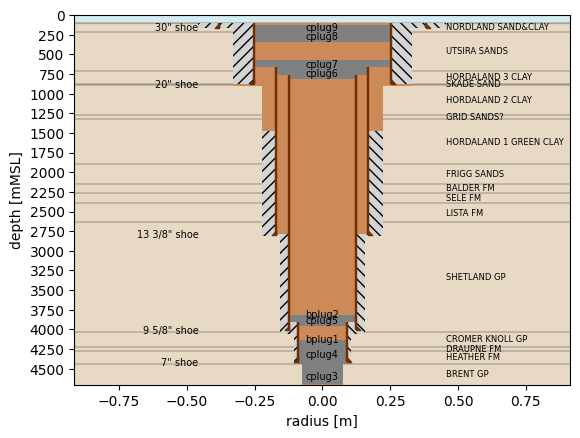

In [58]:
plot_sketch(my_well)

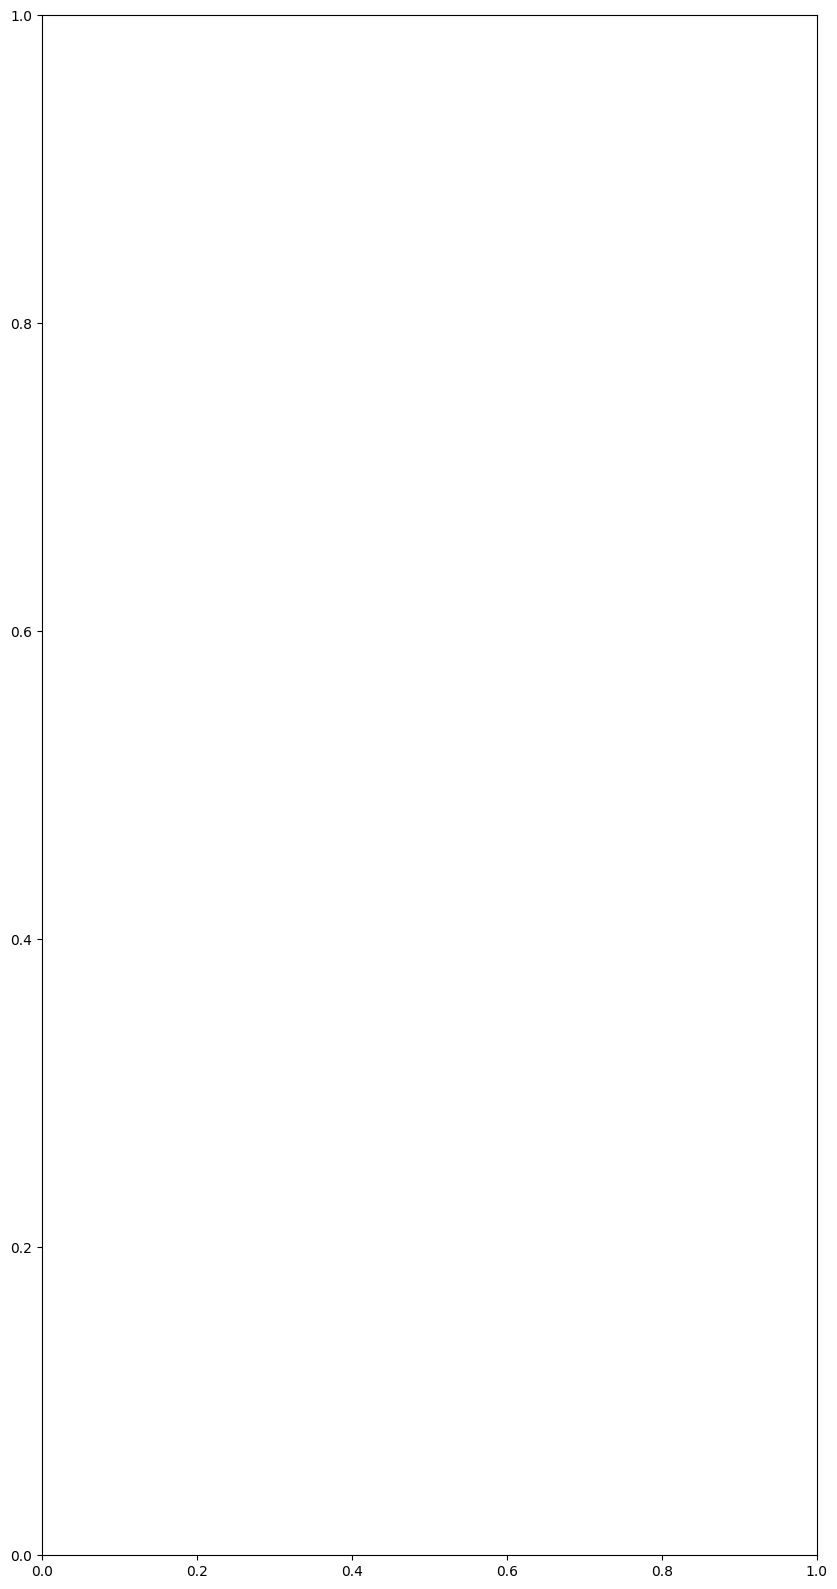

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 20))

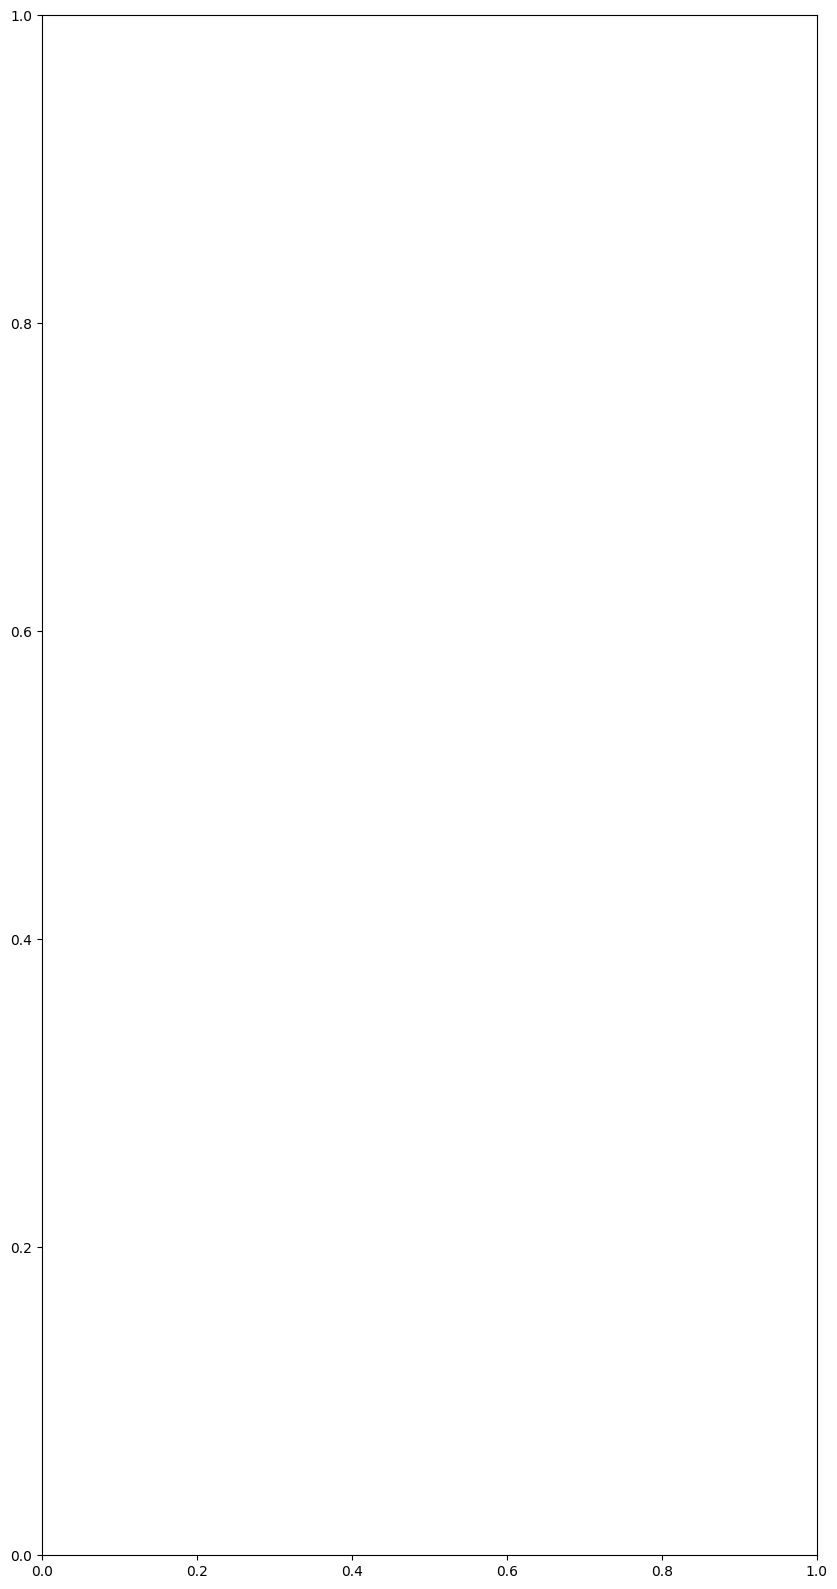

In [47]:
ax.figure

In [ ]:
processed_plugs = my_well.processed_plugs
plug_names = my_well.plug_names
eval_plug = 'cplug6'


from typing import Callable, Dict, List, Optional, Any



def compute_barrier_properties(processed_plugs:List[Dict[str,Any]], plug_names:List[str], eval_plug:str) -> Dict[str, Any]:


    if eval_plug in plug_names:



        barrier_props = {}

        matching_items = [plug for plug in processed_plugs if plug.get('name') == eval_plug]
        matching_items = sorted(matching_items, key=lambda x: x['top_rkb'])

        top_rkb = matching_items[0]['top_rkb']
        bottom_rkb = matching_items[-1]['bottom_rkb']
        top_tvd_msl = matching_items[0]['top_tvd_msl']
        bottom_tvd_msl = matching_items[-1]['bottom_tvd_msl']

        thickness_tvd = bottom_tvd_msl - top_tvd_msl
        thickness_md = bottom_rkb - top_rkb

        avg_diam = 0

        for item in matching_items:
            segment_thickness_md = item['bottom_rkb'] - item['top_rkb']
            segment_thickness_tvd = item['bottom_tvd_msl'] - item['top_tvd_msl']
            segment_diameter = item['diameter_m']

            avg_diam += segment_diameter * segment_thickness_md

        avg_diam /= thickness_md

        plug_radius = avg_diam / 2

        barrier_props['name'] = eval_plug
        barrier_props['top_rkb'] = top_rkb
        barrier_props['bottom_rkb'] = bottom_rkb
        barrier_props['top_tvd_msl'] = float(top_tvd_msl)
        barrier_props['bottom_tvd_msl'] = float(bottom_tvd_msl)
        barrier_props['thickness_tvd'] = float(thickness_tvd)
        barrier_props['thickness_md'] = float(thickness_md)
        barrier_props['radius'] = plug_radius


        return barrier_props        

    else:
        raise ValueError(f"Plug name '{eval_plug}' not found in plug_names list.")



barrier_properties = compute_barrier_properties(processed_plugs, plug_names, 'sdfds')

In [ ]:
barrier_properties

In [ ]:
from typing import Any, Dict, List, Optional



def _compute_plugs_diameter(plugs:List[Dict[str,Any]], borehole:List[Dict[str,Any]]) -> List[Dict[str,Any]]:

    plugs_processed = []

    for plug in plugs:
        plug_name = plug['name']
        plug_top = plug['top_rkb']
        plug_bottom = plug['bottom_rkb']
        plug_cement_perm = plug.get('cement_perm', None)

        # Find borehole sections that overlap with the plug
        borehole_plug_top = [bh for bh in borehole if bh['top_rkb'] <= plug_top <= bh['bottom_rkb']]
        borehole_plug_bottom = [bh for bh in borehole if bh['top_rkb'] <= plug_bottom <= bh['bottom_rkb']]

        # Cement plug intervals should be defined within the borehole sections, if these return empty, data must be wrong
        if not borehole_plug_top or not borehole_plug_bottom:
            raise ValueError(f"Plug '{plug_name}' has top or bottom intervals that do not overlap with any borehole sections. Please check the data.")
            
        borehole_plug_top_diameter = borehole_plug_top[0]['diameter_m']
        borehole_plug_bottom_diameter = borehole_plug_bottom[0]['diameter_m']

        if borehole_plug_top_diameter == borehole_plug_bottom_diameter:
            plugs_processed.append({
                'name': plug_name,
                'segment':0,

                'top_rkb': plug_top,
                'bottom_rkb': plug_bottom,
                'diameter_m': borehole_plug_top_diameter,
                'cement_perm': plug_cement_perm
            })
        
        else:
            borehole_subsections = [bh for bh in borehole if borehole_plug_bottom_diameter <= bh['diameter_m'] <= borehole_plug_top_diameter]

            for idx, subsection in enumerate(borehole_subsections):
                plugs_processed.append({
                    'name': plug_name,
                    'segment': idx,
                    'top_rkb': max(plug_top, subsection['top_rkb']),
                    'bottom_rkb': min(plug_bottom, subsection['bottom_rkb']),
                    'diameter_m': subsection['diameter_m'],
                    'cement_perm': plug_cement_perm
                })

    return plugs_processed


plugs = my_well.plugs
borehole = my_well.borehole

pd.DataFrame(_compute_barriers_diam(plugs, borehole))


In [ ]:
plugs

In [ ]:
pd.DataFrame(my_well.cement_bond)

In [ ]:
casings

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
fig, ax = plt.subplots(figsize=(12, 30))

min_x = np.inf
max_x = -np.inf
min_y = np.inf
max_y = -np.inf

# colo

cmap = plt.cm.turbo

for interval in my_well.annulus:
    top = interval['top_tvd_msl']
    bottom = interval['bottom_tvd_msl']
    width = interval['od_m'] - interval['id_m']
    left = interval['id_m']
    height = bottom - top

    if top < min_y:
        min_y = top
    if bottom > max_y:
        max_y = bottom
    if left < min_x:
        min_x = left
    if left + width > max_x:
        max_x = left + width

    rect = patches.Rectangle((left, top), width, height, edgecolor='black', facecolor=cmap(left), alpha=0.5)
    ax.add_patch(rect)

for interval in my_well.cement_bond:
    top = interval['top_tvd_msl']
    bottom = interval['bottom_tvd_msl']
    width = interval['od_m'] - interval['id_m']
    left = interval['id_m']
    height = bottom - top

    if top < min_y:
        min_y = top
    if bottom > max_y:
        max_y = bottom
    if left < min_x:
        min_x = left
    if left + width > max_x:
        max_x = left + width

    rect = patches.Rectangle((left, top), width, height, facecolor='gray', alpha=1)
    ax.add_patch(rect)





ax.set_xlim(min_x*0.9, max_x * 1.1)
ax.set_ylim(min_y*0.9, max_y * 1.1)


In [ ]:
test_run

In [ ]:
pd.DataFrame(my_well.hole_casings).query('type == "casing"').sort_values('bottom_rkb', ascending=True)

In [ ]:
pd.DataFrame(my_well.hole_casings).query('type == "hole"').sort_values('bottom_rkb', ascending=True)

In [ ]:
pd.DataFrame(my_well.hole_casings).query('type == "casing cement"').sort_values('bottom_rkb', ascending=True)

In [ ]:
pd.DataFrame(my_well.plugs)

In [ ]:
my_well.header

In [ ]:
splitted = split_hole_casings(my_well.hole_casings)

holes = splitted['holes']
casings = splitted['casing']

# from src.WellClass.libs.well_computed.borehole import compute_borehole

pd.DataFrame(compute_borehole(casings, holes))